## Linear Classifier in TensorFlow 
Using Low Level API in Eager Execution mode

### Load tensorflow

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
#Enable Eager Execution if using tensflow version < 2.0
#From tensorflow v2.0 onwards, Eager Execution will be enabled by default


### Collect Data

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
from pandas import get_dummies
from sklearn.model_selection import train_test_split
# Config the matlotlib backend as plotting inline in IPython
%matplotlib inline
from matplotlib import pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, regularizers, Input
from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import np_utils
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

Using TensorFlow backend.


In [17]:
tfp = pd.read_csv('prices.csv')

### Check all columns in the dataset

### Drop columns `date` and  `symbol`

In [20]:
tfp = tfp.drop(['date','symbol'], axis =1 )

In [21]:
tfp.head()

,open,close,low,high,volume
0,123.430000,125.839996,122.309998,126.250000,2163600.0
1,125.239998,119.980003,119.940002,125.540001,2386400.0
2,116.379997,114.949997,114.930000,119.739998,2489500.0
3,115.480003,116.620003,113.500000,117.440002,2006300.0
4,117.010002,114.970001,114.089996,117.330002,1408600.0


### Consider only first 1000 rows in the dataset for building feature set and target set
Target 'Volume' has very high values. Divide 'Volume' by 1000,000

In [23]:
tfp['volume'] = tfp['volume']/100000

In [24]:
tfp = tfp.head(1000)

### Divide the data into train and test sets

In [25]:
from sklearn.model_selection import train_test_split

X =  tfp.drop("volume", axis=1)
y =  tfp.pop("volume")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

#### Convert Training and Test Data to numpy float32 arrays


In [26]:
import numpy as np
X_train = np.asarray(X_train)
y_train = np.asarray(y_train)
X_train.shape

(700, 4)

### Normalize the data
You can use Normalizer from sklearn.preprocessing

In [27]:
from sklearn import preprocessing
X_normalized = preprocessing.normalize(X, norm='l2')

## Building the Model in tensorflow

1.Define Weights and Bias, use tf.zeros to initialize weights and Bias

In [28]:
x = tf.placeholder(shape=[None,4],dtype=tf.float32, name='x-input')
x_n = tf.nn.l2_normalize(x,1)
y_ = tf.placeholder(shape=[None],dtype=tf.float32, name='y-input')

W = tf.Variable(tf.zeros(shape=[4,1]), name="Weights")
b = tf.Variable(tf.zeros(shape=[1]),name="Bias")

2.Define a function to calculate prediction

In [29]:
y = tf.add(tf.matmul(x_n,W),b,name='output')

3.Loss (Cost) Function [Mean square error]

In [30]:
loss = tf.reduce_mean(tf.square(y-y_),name='Loss')

4.Function to train the Model

1.   Record all the mathematical steps to calculate Loss
2.   Calculate Gradients of Loss w.r.t weights and bias
3.   Update Weights and Bias based on gradients and learning rate to minimize loss

In [31]:
train_op = tf.train.GradientDescentOptimizer(0.03).minimize(loss)

## Train the model for 100 epochs 
1. Observe the training loss at every iteration
2. Observe Train loss at every 5th iteration

In [32]:
sess = tf.Session()
sess.run(tf.global_variables_initializer())
training_epochs = 100

In [33]:
for epoch in range(training_epochs):
    _, train_loss = sess.run([train_op,loss],feed_dict={x:X_train, y_:y_train})
    if epoch % 5 == 0:
        print ('Training loss at step: ', epoch, ' is ', train_loss)

Training loss at step:  0  is  22587.957
Training loss at step:  5  is  20389.14
Training loss at step:  10  is  19776.738
Training loss at step:  15  is  19606.19
Training loss at step:  20  is  19558.684
Training loss at step:  25  is  19545.453
Training loss at step:  30  is  19541.77
Training loss at step:  35  is  19540.754
Training loss at step:  40  is  19540.46
Training loss at step:  45  is  19540.377
Training loss at step:  50  is  19540.361
Training loss at step:  55  is  19540.346
Training loss at step:  60  is  19540.357
Training loss at step:  65  is  19540.357
Training loss at step:  70  is  19540.348
Training loss at step:  75  is  19540.352
Training loss at step:  80  is  19540.348
Training loss at step:  85  is  19540.348
Training loss at step:  90  is  19540.35
Training loss at step:  95  is  19540.352


### Get the shapes and values of W and b

In [34]:
W.shape

TensorShape([Dimension(4), Dimension(1)])

In [35]:
b.shape

TensorShape([Dimension(1)])

### Model Prediction on 1st Examples in Test Dataset

In [36]:
test_loss = sess.run([loss],feed_dict={x:X_test, y_:y_test})
print ('Training loss at step:is ', test_loss)

Training loss at step:is  [24101.951]


## Classification using tf.Keras

In this exercise, we will build a Deep Neural Network using tf.Keras. We will use Iris Dataset for this exercise.

### Load the given Iris data using pandas (Iris.csv)

In [38]:
# load dataset
df = pd.read_csv("iris.csv")

In [39]:
df.dtypes
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Target set has different categories. So, Label encode them. And convert into one-hot vectors using get_dummies in pandas.

In [40]:
df= df.drop('Id',axis=1)
df = df.values
X = df[:,0:4].astype(float)
Y = df[:,4]

In [41]:
# encode class values as integers
encoder = LabelEncoder()
encoded_Y = encoder.fit_transform(Y)

# convert integers to dummy variables (i.e. one hot encoded)
dummy_y = np_utils.to_categorical(encoded_Y)

In [42]:
dummy_y

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

### Splitting the data into feature set and target set

In [43]:
# done

###  Building Model in tf.keras

Build a Linear Classifier model  <br>
1.  Use Dense Layer  with input shape of 4 (according to the feature set) and number of outputs set to 3<br> 
2. Apply Softmax on Dense Layer outputs <br>
3. Use SGD as Optimizer
4. Use categorical_crossentropy as loss function 

In [45]:

# define baseline model
def baseline_model():
    
    model = Sequential()
    model.add(Dense(8, input_dim=4, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model
estimator = KerasClassifier(build_fn=baseline_model, epochs=200, batch_size=5, verbose=0)
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
results = cross_val_score(estimator, X, dummy_y, cv=kfold)
print("Baseline: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Instructions for updating:
Use tf.cast instead.
Baseline: 96.00% (6.11%)


### Model Training 

In [50]:
def small_model():
    
    model = Sequential()
    model.add(Dense(4, kernel_initializer='normal', input_dim=4, activation='relu'))
    model.add(Dense(3, kernel_initializer='normal', activation='softmax'))
    
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model

estimator = KerasClassifier(build_fn=small_model, epochs=200, batch_size=5, verbose=0)
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
results = cross_val_score(estimator, X, dummy_y, cv=kfold)
print("small model: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

small model: 98.00% (4.27%)


In [51]:
def larger_model():
    
    model = Sequential()
    model.add(Dense(8, input_dim=4, kernel_initializer='normal', activation='relu'))
    model.add(Dense(6, kernel_initializer='normal', activation='relu'))
    model.add(Dense(4, kernel_initializer='normal', activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model
estimator = KerasClassifier(build_fn=larger_model, epochs=200, batch_size=5, verbose=0)
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
results = cross_val_score(estimator, X, dummy_y, cv=kfold)
print("Larger model: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Larger model: 51.33% (33.74%)


In [52]:
def tune_model():
    
    model = Sequential()
    model.add(Dense(16, input_dim=4, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.001), activation='relu'))
    model.add(Dense(8, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.001), activation='relu'))
    model.add(Dense(8, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.001), activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model

estimator = KerasClassifier(build_fn=tune_model, epochs=200, batch_size=5, verbose=0)
kfold = KFold(n_splits=8, shuffle=True, random_state=seed)
results = cross_val_score(estimator, X, dummy_y, cv=kfold)
print("Tune model: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Tune model: 73.79% (28.37%)


### Model Prediction

Epoch 1/200
150/150 [==============================] - 2s 12ms/step - loss: 1.0976 - acc: 0.3400
Epoch 2/200
150/150 [==============================] - 0s 650us/step - loss: 1.0964 - acc: 0.4733
Epoch 3/200
150/150 [==============================] - 0s 970us/step - loss: 1.0951 - acc: 0.4800
Epoch 4/200
150/150 [==============================] - 0s 930us/step - loss: 1.0924 - acc: 0.3667
Epoch 5/200
150/150 [==============================] - 0s 850us/step - loss: 1.0892 - acc: 0.4333
Epoch 6/200
150/150 [==============================] - 0s 737us/step - loss: 1.0843 - acc: 0.4667
Epoch 7/200
150/150 [==============================] - 0s 482us/step - loss: 1.0775 - acc: 0.6200
Epoch 8/200
150/150 [==============================] - 0s 417us/step - loss: 1.0674 - acc: 0.6200
Epoch 9/200
150/150 [==============================] - 0s 312us/step - loss: 1.0535 - acc: 0.5533
Epoch 10/200
150/150 [==============================] - 0s 312us/step - loss: 1.0334 - acc: 0.6133
Epoch 11/200
150/150

150/150 [==============================] - 0s 417us/step - loss: 0.3965 - acc: 0.9533
Epoch 84/200
150/150 [==============================] - 0s 417us/step - loss: 0.3883 - acc: 0.9533
Epoch 85/200
150/150 [==============================] - 0s 417us/step - loss: 0.3848 - acc: 0.9533
Epoch 86/200
150/150 [==============================] - 0s 417us/step - loss: 0.3805 - acc: 0.9467
Epoch 87/200
150/150 [==============================] - 0s 417us/step - loss: 0.3776 - acc: 0.9600
Epoch 88/200
150/150 [==============================] - 0s 312us/step - loss: 0.3719 - acc: 0.9667
Epoch 89/200
150/150 [==============================] - 0s 417us/step - loss: 0.3687 - acc: 0.9467
Epoch 90/200
150/150 [==============================] - 0s 521us/step - loss: 0.3661 - acc: 0.9533
Epoch 91/200
150/150 [==============================] - 0s 625us/step - loss: 0.3628 - acc: 0.9667
Epoch 92/200
150/150 [==============================] - 0s 729us/step - loss: 0.3603 - acc: 0.9467
Epoch 93/200
150/150 [=

150/150 [==============================] - 0s 312us/step - loss: 0.2097 - acc: 0.9533
Epoch 166/200
150/150 [==============================] - 0s 417us/step - loss: 0.2091 - acc: 0.9600
Epoch 167/200
150/150 [==============================] - 0s 300us/step - loss: 0.2035 - acc: 0.9733
Epoch 168/200
150/150 [==============================] - 0s 313us/step - loss: 0.2070 - acc: 0.9733
Epoch 169/200
150/150 [==============================] - 0s 312us/step - loss: 0.2029 - acc: 0.9733
Epoch 170/200
150/150 [==============================] - 0s 312us/step - loss: 0.2015 - acc: 0.9667
Epoch 171/200
150/150 [==============================] - 0s 312us/step - loss: 0.1987 - acc: 0.9667
Epoch 172/200
150/150 [==============================] - 0s 312us/step - loss: 0.2026 - acc: 0.9667
Epoch 173/200
150/150 [==============================] - 0s 312us/step - loss: 0.2005 - acc: 0.9600
Epoch 174/200
150/150 [==============================] - 0s 312us/step - loss: 0.1939 - acc: 0.9733
Epoch 175/200


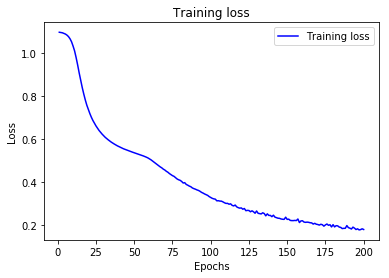

In [53]:
model= small_model()
result = model.fit(X, dummy_y, epochs=200, batch_size=5)
acc = result.history['acc']
loss = result.history['loss']
#val_loss = result.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, loss, 'b', label='Training loss')
#plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Save the Model

In [54]:
# serialize model to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("model.h5")
print("Saved model to disk")

Saved model to disk


### Build and Train a Deep Neural network with 2 hidden layer  - Optional - For Practice

Does it perform better than Linear Classifier? What could be the reason for difference in performance?

In [55]:
#done as above